In [69]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(repo_root))

import SysSimX
from SysSimX.utilities.units import ureg
from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum

# from pendulum_multi_comp import PendulumMultiComp
from pendulum_multi import PendulumMultiComp

In [70]:
fmu_pendulum_path = Path.cwd() / 'FMUs/Pendulum.fmu'

eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

In [ ]:
fem_pendulum._use_gravity = False
fem_pendulum._with_contact = False
fem_pendulum.anim_params.animate = False

In [72]:
pendulum = PendulumMultiComp(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = 0.01
t_end = 10
fem_pendulum.sim_params.t_end = t_end

pendulum.initialize(t)

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [73]:
# Analytical solution
I = fem_pendulum.inertia
m = fem_pendulum.mass
q0 = np.deg2rad(fem_pendulum.init_params.angular_position_deg)
omega0 = fem_pendulum.init_params.angular_velocity

# q(t+1) = q(t) + omega(t)*dt + 0.5*alpha(t)*dt^2
def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

def determine_torque(t, t_end, torque=1.0):
    interval = t_end / 6 
    if t < interval:
        return t * torque
    elif t < 2 * interval:
        return interval * torque
    elif t < 3 * interval:
        return interval * torque - (t - 2 * interval) * torque
    elif t < 4 * interval:
        return -(t - 3 * interval) * torque
    elif t < 5 * interval:
        return -(interval) * torque
    else:
        return -interval * torque + (t - 5 * interval) * torque

In [74]:
input_torque = 20 # Nm

t_vals = {"EQB": [], "FEM": [], "OpenSim": []}
torque_vals = {"EQB": [], "FEM": [], "OpenSim": []}
alpha_vals = {"EQB": [], "FEM": [], "OpenSim": []}
omega_vals = {"EQB": [], "FEM": [], "OpenSim": []}
q_vals = {"EQB": [], "FEM": [], "OpenSim": []}

t = 0

t_vals[pendulum.active_mode].append(t)
torque_vals[pendulum.active_mode].append(0)
alpha_vals[pendulum.active_mode].append(0)
omega_vals[pendulum.active_mode].append(0)
q_vals[pendulum.active_mode].append(0)

t_an_vals = [t]
q_an_vals = [q0]
omega_an_vals = [omega0]
alpha_an_vals = [0.0]

q_an = q0
omega_an = omega0

while t < t_end:
    torque = determine_torque(t, t_end, input_torque)

    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)
    
    # Perform simulation step
    pendulum.set_inputs({'torque': torque}, t=t)
    pendulum.do_step(t, dt)
    t_next = t + dt
    
    res = pendulum.get_outputs()


    t_vals[pendulum.active_mode].append(t_next)
    torque_vals[pendulum.active_mode].append(torque)
    alpha_vals[pendulum.active_mode].append(res['alpha'].magnitude)
    omega_vals[pendulum.active_mode].append(res['omega'].magnitude)
    q_vals[pendulum.active_mode].append(res['q'].magnitude)
    
    t_an_vals.append(t_next)
    q_an_vals.append(q_an)
    omega_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

    t = t_next

[Pendulum] Switching: OpenSim to FEM @ t=0.0500s


KeyboardInterrupt: 

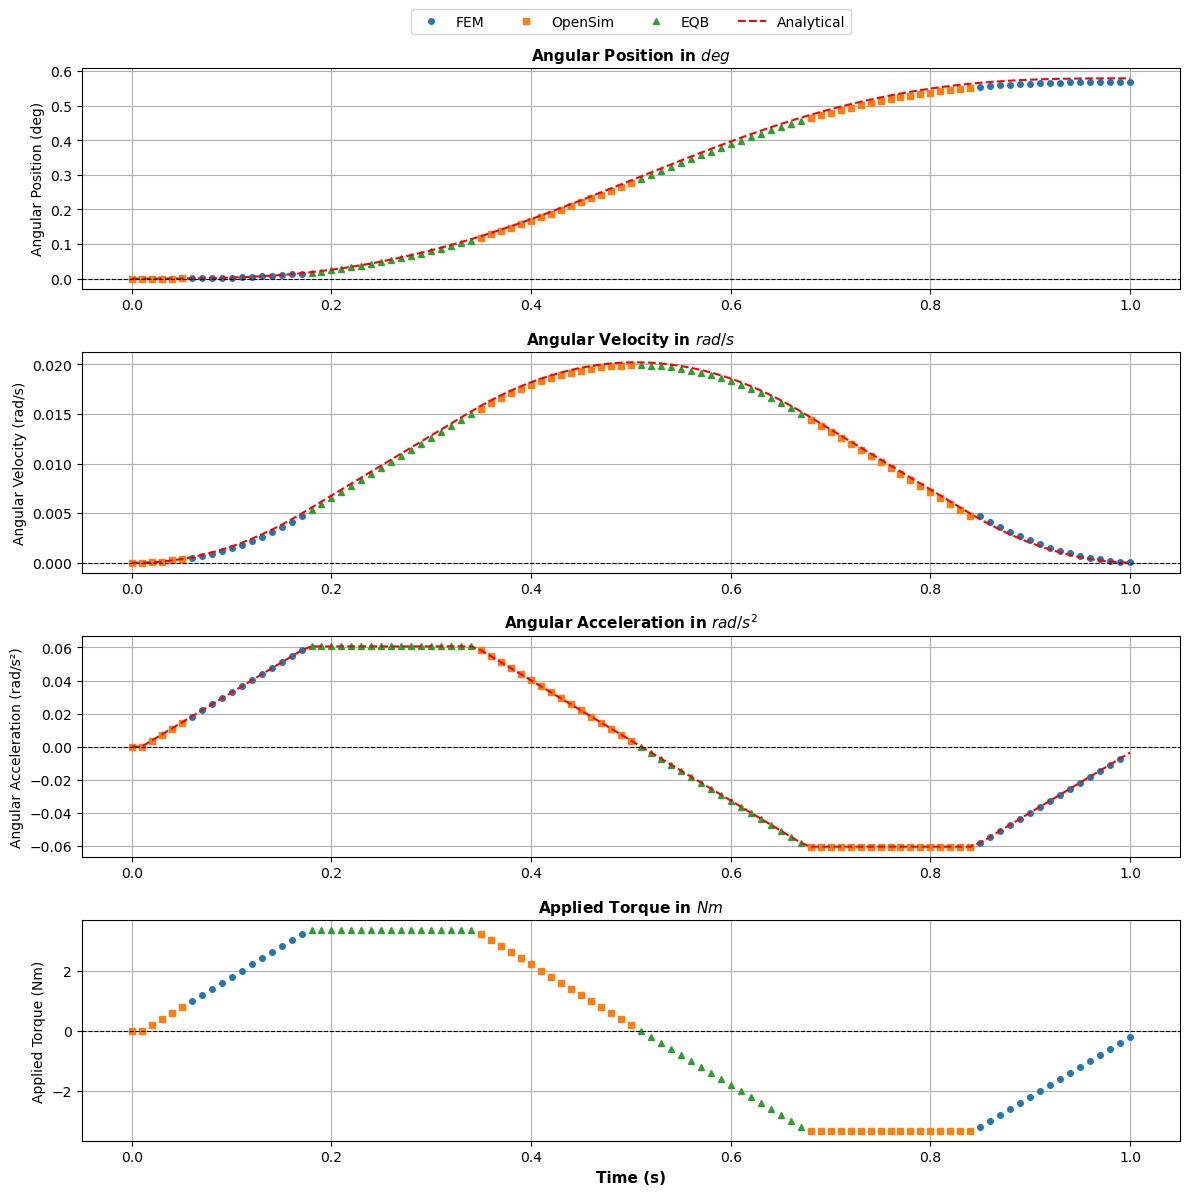

In [ ]:
plt.figure(figsize=(12, 12))

marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}
opensim_style = {'color': 'C1', 'linestyle': 'None', 'marker': 's', 'markersize': marker_size}
eqb_style = {'color': 'C2', 'linestyle': 'None', 'marker': '^', 'markersize': marker_size}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.subplot(4,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals['FEM'], np.rad2deg(q_vals["FEM"]), label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], np.rad2deg(q_vals["OpenSim"]), label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], np.rad2deg(q_vals["EQB"]), label="EQB", **eqb_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)


plt.subplot(4,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals['FEM'], omega_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], omega_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], omega_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(4,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals['FEM'][:-1], alpha_vals["FEM"][:-1], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], alpha_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], alpha_vals["EQB"], label="EQB", **eqb_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.subplot(4,1,4).set_title("Applied Torque in $Nm$", **fontdict)
plt.plot(t_vals['FEM'], torque_vals["FEM"], label="FEM", **fem_style)
plt.plot(t_vals['OpenSim'], torque_vals["OpenSim"], label="OpenSim", **opensim_style)
plt.plot(t_vals["EQB"], torque_vals["EQB"], label="EQB", **eqb_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Applied Torque (Nm)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
plt.savefig("StateSynchronization.svg")
plt.show()